# Telco Customer Churn Data Analysis

The dataset __`WA_Fn-UseC_-Telco-Customer-Churn.csv`__ contains customer information such as demographics, account details, and service usage, with the target variable indicating whether a customer has churned.

## Data Cleaning

This section focuses on preparing the dataset for analysis by handling inconsistencies, missing values, and incorrect data types.

Key steps performed in this section:
- Handling hidden missing values represented as blank spaces
- Converting data types where necessary (e.g., `TotalCharges` to numeric)
- Filling missing values using domain-based estimation
- Checking for duplicate records

These steps ensure the dataset is clean, consistent, and ready for exploratory data analysis and modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [4]:
!python -m pip install --upgrade pip

In [5]:
from xgboost import XGBClassifier

#### Load Data

In [6]:
def load_data(path: str) -> pd.DataFrame:
    """
    Load dataset from a CSV file safely.
    """
    try:
        return pd.read_csv(path)

    except Exception as e:
        raise RuntimeError(f"Failed to load data: {e}")

In [7]:
df = load_data("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### Basic Inspection

In [8]:
def inspect_data(df: pd.DataFrame) -> None:
    """
    Display basic dataset information.
    """
    print("Shape:", df.shape)
    print("\nInfo:")
    print(df.info())
    print("\nMissing Values:")
    print(df.isnull().sum())

In [9]:
inspect_data(df)

Shape: (7043, 21)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-n

In [10]:
# Check for duplicates
df.duplicated().sum()

0

In [11]:
# Display unique values for each column to understand data distribution 
# and identify potential inconsistencies or categorical variations

columns = df.columns
for col in columns:
    print(col, ":", df[col].unique())

customerID : <StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str
gender : <StringArray>
['Female', 'Male']
Length: 2, dtype: str
SeniorCitizen : [0 1]
Partner : <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
tenure : [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
PhoneService : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines : <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService : <StringArray>
['DSL', 'Fiber optic', 'No']
Lengt

***
### Data Overview

The dataset contains __7043 customer records with 21 features__, including demographic information, service usage, and billing details.

##### Data Type Summary:
- Many __categorical features__ → need encoding later
- Few __numeric features__ → will be scaled later

Although no missing values are detected initially, the `TotalCharges` column is stored as an _object (string)_ and may contain hidden missing values represented as _blank spaces_.
***
<br>

In [12]:
# Check blank spaces in all columns
# (df == " ").sum()

# Check one space or multiple spaces in all columns
df.apply(lambda col: col.astype(str).str.strip() == "").sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

***
##### Further inspection across all columns showed that blank values were only present in the `TotalCharges` column.
Therefore, data cleaning is required to:
- Convert `TotalCharges` to numeric format
- Handle hidden missing values
***

#### Fix `TotalCharges` column

In [13]:
# Make a copy
df_clean = df.copy()

# Replace blank spaces with NaN
df_clean["TotalCharges"] = df_clean["TotalCharges"].replace(" ", np.nan)

# Convert to numeric
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")

# Fill missing values using business logic
df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(
    df_clean["MonthlyCharges"] * df_clean["tenure"]
)

***
The blank spaces in the `TotalCharges` column were converted to NaN, and the column was subsequently cast to a numeric data type. Missing values were then imputed using domain knowledge by approximating total charges as the product of `MonthlyCharges` and tenure. 

** While `TotalCharges` is not exactly equal to the product of `MonthlyCharges` and tenure due to real-world billing variations, this approximation was used to impute missing values as it preserves the underlying relationship between features.
***

In [14]:
inspect_data(df_clean)

Shape: (7043, 21)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-n

## Exploratory Data Analysis (EDA)

This section explores the dataset to identify patterns, relationships, and key factors influencing customer churn.

The goal is to gain insights into customer behavior that can guide feature engineering and model development.

In [15]:
# makes plots clean and readable with a white background and grid lines
sns.set_style("whitegrid")

##### Churn Distribution

- The dataset shows an imbalance in churn distribution.
- The majority of customers have not churned.

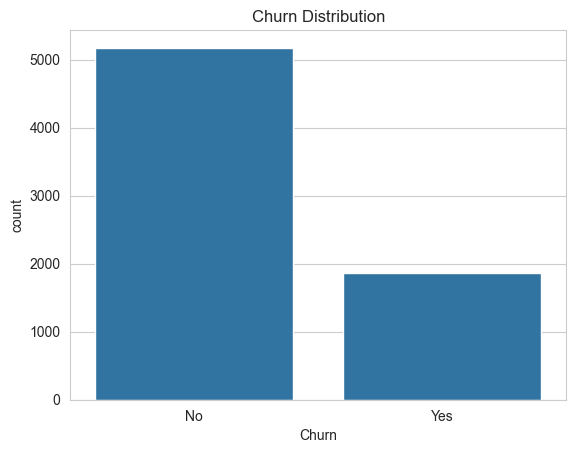

In [16]:
sns.countplot(x="Churn", data=df_clean)
plt.title("Churn Distribution")

plt.savefig("images/churn_distribution.png")
plt.show()

##### Churn vs Contract

- Customers with month-to-month contracts have a significantly higher churn rate.
- Long-term contracts (one year, two year) are associated with lower churn.

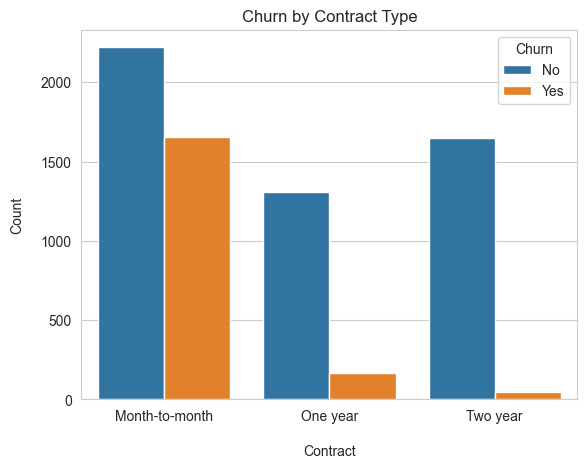

In [17]:
sns.countplot(x="Contract", hue="Churn", data=df_clean)
plt.title("Churn by Contract Type")
plt.ylabel("Count", labelpad=12)
plt.xlabel("Contract", labelpad=15)

plt.savefig("images/contract_vs_churn.png", bbox_inches="tight")
plt.show()

##### Churn vs Tenure
- Customers with shorter tenure are more likely to churn.
- Long-term customers tend to stay.

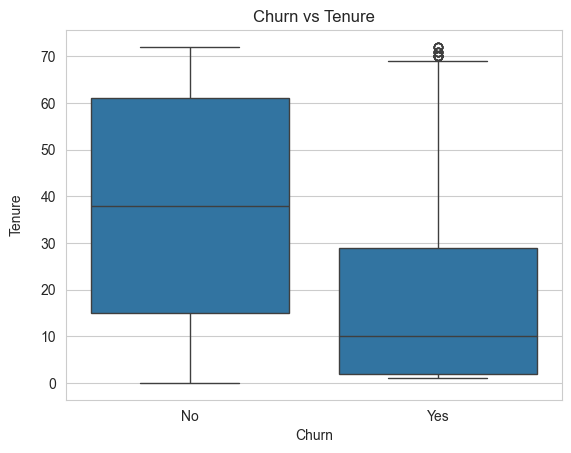

In [18]:
sns.boxplot(x="Churn", y="tenure", data=df_clean)
plt.title("Churn vs Tenure")
plt.ylabel("Tenure", labelpad=12)

plt.savefig("images/tenure_vs_churn.png")
plt.show()

##### Churn vs Monthly Charges
- Customers with higher monthly charges tend to churn more frequently.

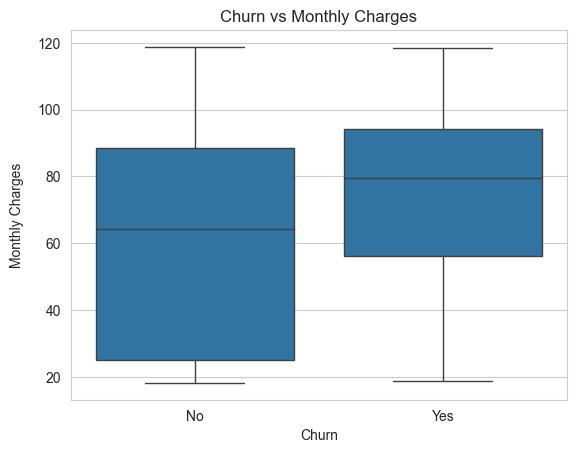

In [19]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df_clean)
plt.title("Churn vs Monthly Charges")
plt.ylabel("Monthly Charges", labelpad=10)

plt.savefig("images/monthlycharges_vs_churn.png")
plt.show()

##### Churn vs Internet Service
- Fiber optic users show higher churn compared to DSL users.

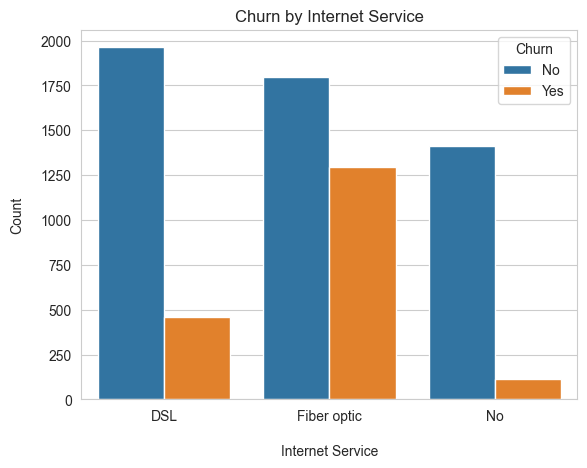

In [20]:
sns.countplot(x="InternetService", hue="Churn", data=df_clean)
plt.title("Churn by Internet Service")
plt.ylabel("Count", labelpad=12)
plt.xlabel("Internet Service", labelpad=15)

plt.savefig("images/internetservice_vs_churn.png", bbox_inches="tight")
plt.show()

##### Correlation
- Tenure shows a strong positive correlation with TotalCharges (0.83), indicating that customers with longer tenure accumulate higher total charges.
- MonthlyCharges has a moderate positive correlation with TotalCharges (0.65), suggesting that higher monthly fees contribute to overall spending.
- MonthlyCharges shows a weak correlation with tenure (0.25), indicating a limited relationship between duration and monthly cost.
- SeniorCitizen has very weak correlations with other numerical features, suggesting minimal direct influence.

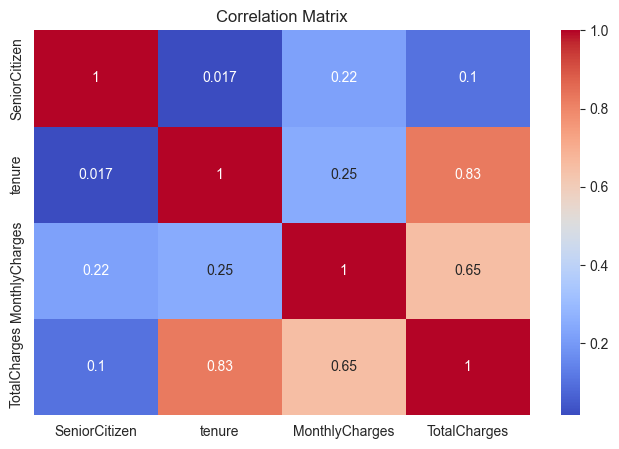

In [21]:
# Select only numerical columns
num_df = df_clean.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(8,5))
sns.heatmap(num_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")

plt.savefig("images/CorrelationMatrix.png")
plt.show()

***
## Key Insights

- Month-to-month contract customers are at high risk of churn
- Customers with shorter tenure are more likely to leave
- Higher monthly charges are associated with increased churn
- Fiber optic users show higher churn rates

These insights will guide feature engineering and model development.
***

## Data Preprocessing

In this section, the dataset is prepared for machine learning by removing non-informative features and converting categorical variables into numerical format.

These steps ensure that the data is suitable for model training.

In [22]:
# Drop customerID column
# WHY: It is just a unique identifier and does not provide any useful information for predicting churn

df_clean = df_clean.drop("customerID", axis=1)

#### - Categorical variables were encoded using label encoding for binary features and one-hot encoding for multi-category features.

#### - Numerical features were standardized using StandardScaler to ensure consistent scale across variables.

##### 1. Label Encoding (for binary columns)

In [23]:
# Binary encoding (Label Encoding)
binary_cols = [
    "gender", "Partner", "Dependents",
    "PhoneService", "PaperlessBilling", "Churn"
]

for col in binary_cols:
    df_clean[col] = df_clean[col].map({
        "Yes": 1, "No": 0,
        "Male": 0, "Female": 1
    })

##### 2. One-Hot Encoding (for multiple categories)

In [24]:
df_clean = pd.get_dummies(
    df_clean,
    columns=[
        "MultipleLines",
        "InternetService",
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies",
        "Contract",
        "PaymentMethod"
    ],
    drop_first=True
)

##### 3. Scaling (for numerical columns)

In [25]:
scaler = StandardScaler()

In [26]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
df_clean[num_cols] = scaler.fit_transform(df_clean[num_cols])

## Train-Test Split

The dataset was divided into training and testing sets to evaluate model performance on unseen data.

- The feature set (X) contains all input variables
- The target variable (y) represents customer churn
- 80% of the data was used for training and 20% for testing

This helps ensure that the model generalizes well and does not overfit the training data.

In [27]:
#Separate Features (X) and Target (y)

# Features (everything except Churn)
X = df_clean.drop("Churn", axis=1)

# Target (what we predict)
y = df_clean["Churn"]

In [28]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
# Train Model (Logistic Regression)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [30]:
# Make Predictions
y_pred = model.predict(X_test)

In [31]:
# Evaluation

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

Accuracy: 0.8218594748048261
Precision: 0.6871165644171779
Recall: 0.6005361930294906
F1-score: 0.6409155937052933


## Results Interpretation

The Logistic Regression model achieved an accuracy of __82.19%__, indicating that it performs well overall in predicting customer churn.

The precision score of __68.71%__ suggests that when the model predicts a customer will churn, it is correct most of the time.

The recall score of __60.05%__ indicates that the model identifies around 60% of actual churn cases. This is an important metric in this problem, as failing to detect customers who are likely to churn may result in lost business opportunities.

The F1-score of __64.09%__ shows a moderate balance between precision and recall.

#### From the confusion matrix:
##### - True Negatives: 934 (correctly predicted non-churn customers)
##### - False Positives: 102 (incorrectly predicted churn)
##### - False Negatives: 149 (missed churn cases)
##### - True Positives: 224 (correctly predicted churn)

Overall, the model performs reasonably well but misses a notable number of churn cases. Improving recall would be beneficial for better identifying at-risk customers.

In [32]:
# Random Forest

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [33]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))

Accuracy: 0.7877927608232789
Precision: 0.6360294117647058
Recall: 0.46380697050938335
F1-score: 0.5364341085271318


In [34]:
# XGBoost

xgb = XGBClassifier()
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [35]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1-score:", f1_score(y_test, y_pred_xgb))

Accuracy: 0.7913413768630234
Precision: 0.6270096463022508
Recall: 0.5227882037533512
F1-score: 0.5701754385964912


#### Confusion Matrix

In [36]:
# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred)
print("Logistic Regression:\n", cm_lr)

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Random Forest:\n", cm_rf)

# XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("XGBoost:\n", cm_xgb)

Logistic Regression:
 [[934 102]
 [149 224]]
Random Forest:
 [[937  99]
 [200 173]]
XGBoost:
 [[920 116]
 [178 195]]


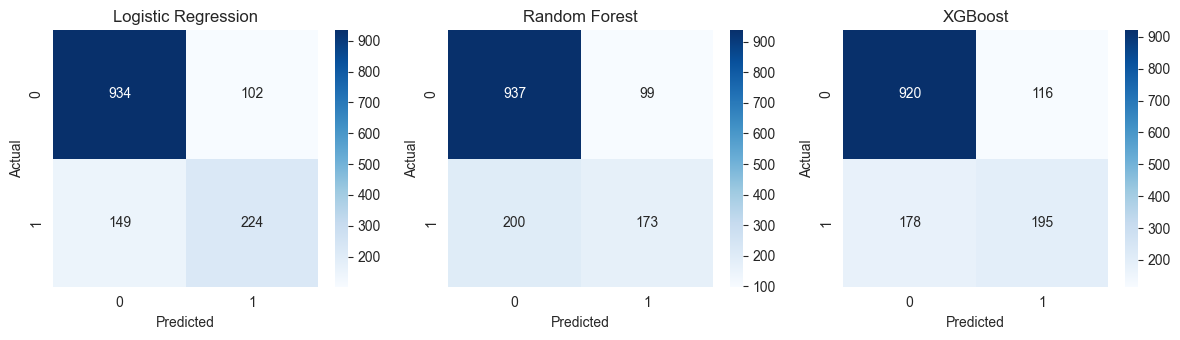

In [37]:
# Create subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

# Logistic Regression
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Random Forest
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("Random Forest")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# XGBoost
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Blues", ax=axes[2])
axes[2].set_title("XGBoost")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()

plt.savefig("images/ConfusionMatrix.png")
plt.show()

#### Model Comparison

Three models were evaluated for churn prediction: Logistic Regression, Random Forest, and XGBoost.

- Logistic Regression achieved the highest accuracy (82.19%) and the best recall (60.05%), making it the most effective model for identifying churn cases.
- Random Forest showed lower recall (45.04%), missing a significant number of churn customers despite reasonable accuracy.
- XGBoost performed better than Random Forest in recall (52.28%) but still underperformed compared to Logistic Regression.

Overall, Logistic Regression outperformed more complex models in this case, indicating that the dataset may not require highly complex models for effective prediction.

In [38]:
# Model Comparison
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [0.8219, 0.7935, 0.7913],
    "Precision": [0.6871, 0.6614, 0.6270],
    "Recall": [0.6005, 0.4504, 0.5228],
    "F1-score": [0.6409, 0.5359, 0.5702]
})

results

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.8219,0.6871,0.6005,0.6409
1,Random Forest,0.7935,0.6614,0.4504,0.5359
2,XGBoost,0.7913,0.6270,0.5228,0.5702


#### Model Selection Criteria

__Recall__ was prioritized over accuracy in model selection, as identifying potential churn customers is critical for retention strategies.

#### Final Model Selection

Based on the evaluation metrics, __Logistic Regression__ was selected as the final model.

Although Random Forest and XGBoost are more complex, they did not outperform Logistic Regression in this case, particularly in terms of recall.

The Logistic Regression model provides the best balance between accuracy and the ability to identify churn customers, making it the most suitable choice for this problem.

## Feature Importance

Feature importance was analyzed using the coefficients of the Logistic Regression model.

The magnitude of each coefficient indicates the strength of its influence on customer churn, while the sign indicates the direction of the relationship.

- Positive coefficients increase the likelihood of churn
- Negative coefficients decrease the likelihood of churn

The top features provide insights into the key factors driving customer churn behavior.

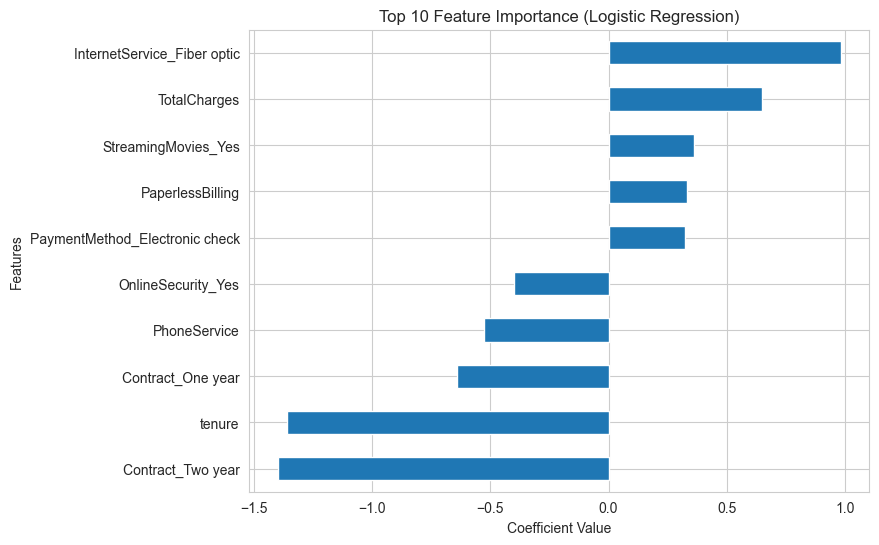

In [39]:
# Get coefficients
importance = model.coef_[0]

# Feature names
features = X.columns

# Create series
feat_importance = pd.Series(importance, index=features)

# Top 10 important features
top_features = feat_importance.abs().nlargest(10).index

# Plot (horizontal)
plt.figure(figsize=(8,6))
feat_importance[top_features].sort_values().plot(kind="barh")

plt.title("Top 10 Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")

plt.savefig("images/feature_importance.png", bbox_inches="tight")
plt.show()

#### Feature Importance Interpretation

The feature importance analysis highlights the key factors influencing customer churn.

- InternetService_Fiber optic shows the strongest positive impact on churn, indicating that customers using fiber optic internet are more likely to leave.
- Contract_Two year shows the strongest negative impact, suggesting that customers with long-term contracts are significantly less likely to churn.

Other important features include tenure and monthly charges, which also contribute to churn behavior.

Overall, service type and contract duration appear to be the most influential factors affecting customer retention.

***

## Business Insights

The primary objective of this project is not only to build a predictive model but also to derive actionable business insights for reducing customer churn.

### High-Risk Customers

Based on model analysis, customers with the following characteristics are more likely to churn:

- Customers with **month-to-month contracts** are significantly more likely to churn compared to long-term contract users.
- **Short tenure customers** represent a high-risk segment, indicating that early-stage customer experience is critical.
- Customers with **higher monthly charges** show a higher tendency to churn, suggesting pricing sensitivity.

### Business Recommendations:
- Focus retention strategies on month-to-month contract users.
- Provide onboarding support and engagement programs for new customers (low tenure segment).
- Introduce targeted discounts or loyalty benefits for high monthly charge customers.
- Improve early customer experience to reduce churn in the first few months.

## Key Insight

The model shows that churn is more influenced by contract type, tenure, and monthly charges rather than demographic features.

This suggests that customer engagement and pricing strategy play a major role in churn behavior.

***

***
***

### Final Conclusion:
This project demonstrates that customer churn is primarily driven by contract type, tenure, and monthly charges. Machine learning models can effectively identify at-risk customers, enabling proactive retention strategies that can reduce revenue loss.

***
***